# Real-Time Sentiment on German Amazon Reviews
**Student:** Niyathi Lekkala  
**Course:** Deep Learning — Final Project  
**Runtime:** Google Colab (GPU recommended)

## Abstract
I build a sentiment classifier for German Amazon reviews, comparing a classical baseline (TF-IDF + Logistic Regression) with a multilingual Transformer (XLM-RoBERTa). I map 1–5 stars → sentiment: negative (1–2), neutral (3), positive (4–5), report Accuracy & Macro-F1, visualize confusion matrices, and provide an inference helper suitable for a simple real-time demo.


## 1) Setup
Install pinned library versions and import core modules.

In [ ]:
# %%capture
!pip -q install "transformers<5" "datasets<3" accelerate sentencepiece \
                scikit-learn matplotlib seaborn pandas joblib torch

# ---- Imports (all in one place) ----
import os, random, json, pathlib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize

import torch, transformers
from datasets import load_dataset, Dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,pipeline,
                          TrainingArguments, Trainer, TextClassificationPipeline)

import ipywidgets as widgets
from IPython.display import display
from sklearn.calibration import calibration_curve
import time


# visuals + style
sns.set_context("talk")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"] = str(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Quiet down W&B
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

print("Transformers:", transformers.__version__, "| Datasets pinned <3: OK")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 18.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
Transformers: 4.57.2 | Datasets pinned <3: OK
GPU: Tesla T4


In [ ]:
# Helper
from pathlib import Path
import matplotlib.pyplot as plt
FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

def savefig(name):
    path = FIGDIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)


## (a) Data Analysis — Load Real Dataset
We use **Hugging Face Datasets**: `amazon_reviews_multi` (German split).  
No uploads/Drive needed. Splits provided: `train`, `validation`, `test`.


In [ ]:
de=pd.read_csv("amazon_reviews.csv")
de
display(de.head())
de.shape

,Unnamed: 0,review_id,product_id,reviewer_id,stars,review_body,review_title,language,product_category
0,0,de_0784695,product_de_0572654,reviewer_de_0645436,1,"Leider, leider nach einmal waschen ausgebliche...",Leider nicht zu empfehlen,de,home
1,1,de_0759207,product_de_0567331,reviewer_de_0183703,1,zunächst macht der Anker Halter einen soliden ...,Gummierung nach 6 Monaten kaputt,de,wireless
2,2,de_0711785,product_de_0482105,reviewer_de_0182152,1,Siegel sowie Verpackung war beschädigt und war...,Flohmarkt ware,de,industrial_supplies
3,3,de_0964430,product_de_0616480,reviewer_de_0991563,1,Habe dieses Produkt NIE erhalten und das Geld ...,Katastrophe,de,industrial_supplies
4,4,de_0474538,product_de_0228702,reviewer_de_0316188,1,Die Träger sind schnell abgerissen,Reißverschluss klemmt,de,luggage


(30000, 9)

## (b) Discover & Visualize
Normalize columns to `review_body` and `stars`, quick EDA: text length distribution, star histogram, and a few examples.


In [ ]:
csv_path = "amazon_reviews.csv"
df = pd.read_csv(csv_path)

text_col  = next((c for c in df.columns if c.lower() in ["review_body","review","text","reviewtext","content"]), None)
stars_col = next((c for c in df.columns if c.lower() in ["stars","rating","star_rating","overall"]), None)
assert text_col and stars_col, f"Couldn't find text/rating columns. Columns are: {list(df.columns)}"

df = df[[text_col, stars_col]].rename(columns={text_col:"review_body", stars_col:"stars"}).dropna()

# clean and keep valid star range
df["review_body"] = (df["review_body"].astype(str).str.replace(r"\s+"," ", regex=True).str.strip())
df["stars"] = pd.to_numeric(df["stars"], errors="coerce").round().astype(int)
df = df[df["stars"].between(1,5)].reset_index(drop=True)

# stratified split 70:15:15
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["stars"], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["stars"], random_state=42)

for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(name, d.shape, d["stars"].value_counts().sort_index().to_dict())


train (21000, 2) {1: 4200, 2: 4200, 3: 4200, 4: 4200, 5: 4200}
val (4500, 2) {1: 900, 2: 900, 3: 900, 4: 900, 5: 900}
test (4500, 2) {1: 900, 2: 900, 3: 900, 4: 900, 5: 900}


## (c) Data Preprocessing — Label Mapping
Map stars → sentiment classes:
- 1–2 → **negative** (0)  
- 3   → **neutral**  (1)  
- 4–5 → **positive** (2)


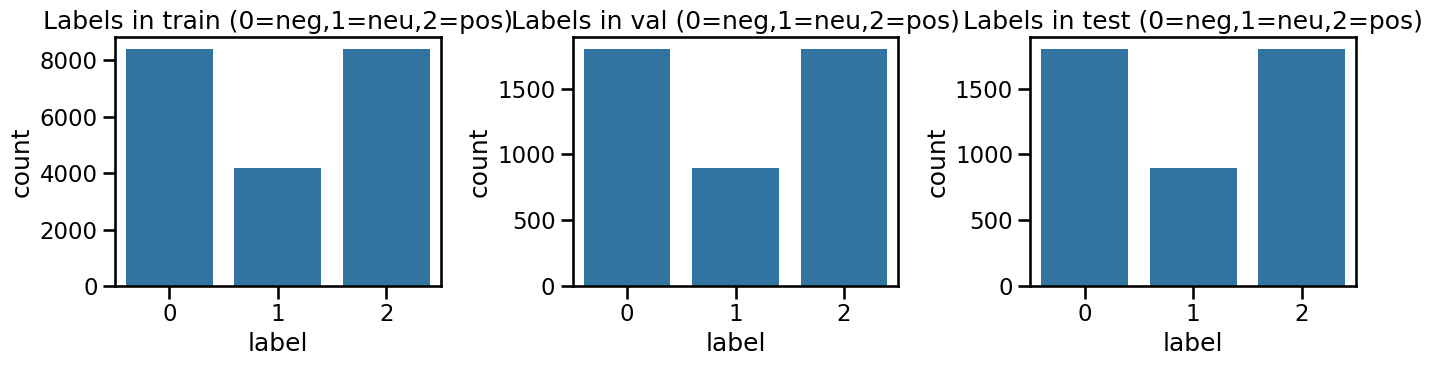

,review_body,stars,label
19237,Géniale pour mon métier d'assistante maternell...,5,2
1388,Schneebesen war sehr schnell defekt (Silikonum...,2,0
8978,Love the shirt. I wish the fabric of the shirt...,4,2


In [ ]:
def stars_to_label(star: int) -> int:
    if star <= 2: return 0
    if star == 3: return 1
    return 2

for df in (train_df, val_df, test_df):
    df["label"] = df["stars"].astype(int).map(stars_to_label)

fig, ax = plt.subplots(1,3, figsize=(14,4))
for i,(name,df) in enumerate([("train",train_df),("val",val_df),("test",test_df)]):
    sns.countplot(x=df["label"], ax=ax[i]); ax[i].set_title(f"Labels in {name} (0=neg,1=neu,2=pos)")
plt.tight_layout(); plt.show()

train_df.head(3)


Saved: figures/Figure-EDA-Stars.png


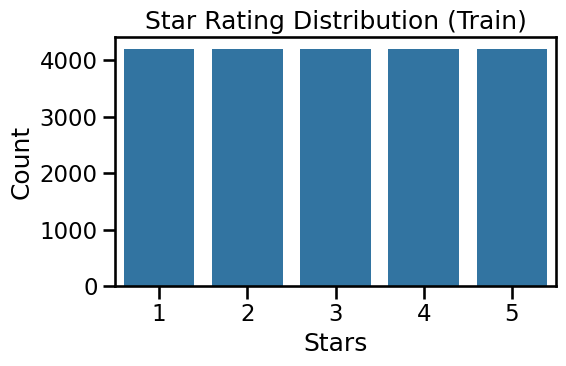

Saved: figures/Figure-EDA-Lengths.png


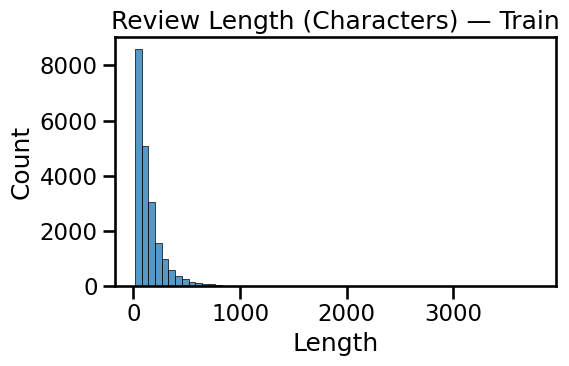

In [ ]:
# FIGURE: Star distribution (Train)
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x=train_df["stars"], ax=ax)
ax.set_title("Star Rating Distribution (Train)")
ax.set_xlabel("Stars"); ax.set_ylabel("Count")
savefig("Figure-EDA-Stars")
plt.show()

# FIGURE: Review length histogram (Train)
lens = train_df["review_body"].str.len()
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(lens, bins=60, ax=ax)
ax.set_title("Review Length (Characters) — Train")
ax.set_xlabel("Length"); ax.set_ylabel("Count")
savefig("Figure-EDA-Lengths")
plt.show()


## (d) Baseline Model — TF-IDF + Logistic Regression
I train on `train`, evaluate on `test`. This gives a fast, explainable reference to compare with the Transformer.


Baseline — TF-IDF + LR
              precision    recall  f1-score   support

           0     0.5623    0.8772    0.6853      1800
           1     0.4422    0.0978    0.1601       900
           2     0.7160    0.5939    0.6493      1800

    accuracy                         0.6080      4500
   macro avg     0.5735    0.5230    0.4982      4500
weighted avg     0.5998    0.6080    0.5659      4500



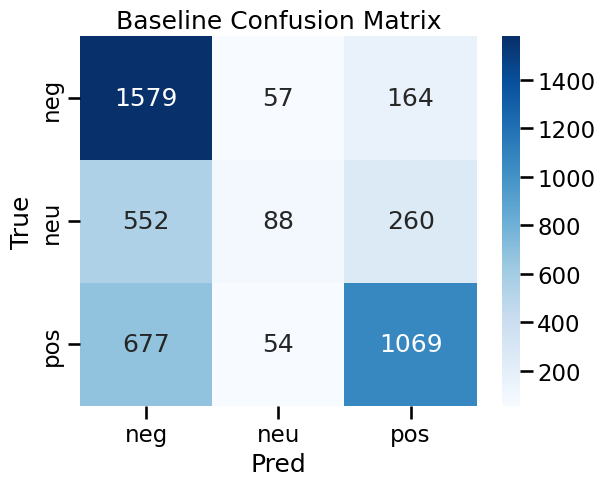

In [ ]:
X_train, y_train = train_df["review_body"], train_df["label"]
X_test,  y_test  = test_df["review_body"],  test_df["label"]

baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50_000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=300, solver="lbfgs", random_state=42))
]).fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
print("Baseline — TF-IDF + LR")
print(classification_report(y_test, y_pred_base, digits=4))

sns.heatmap(confusion_matrix(y_test, y_pred_base, labels=[0,1,2]),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg","neu","pos"], yticklabels=["neg","neu","pos"])
plt.title("Baseline Confusion Matrix"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()


In [ ]:
# earlier
X_test  = test_df["review_body"]
y_test  = test_df["label"]
y_pred_base = baseline.predict(X_test)


Saved: figures/Figure-Baseline-CM-Counts.png


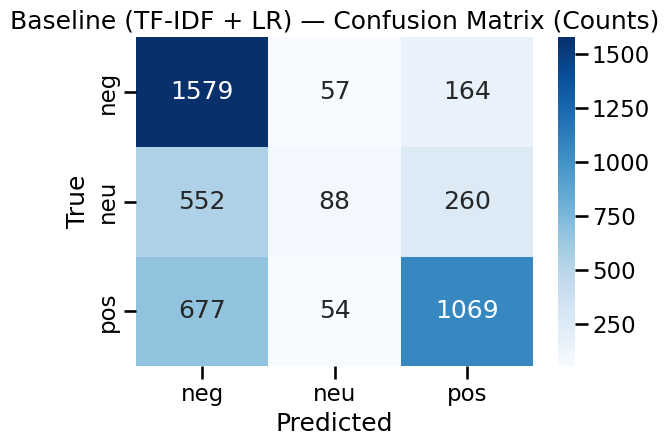

Saved: figures/Figure-Baseline-PR.png


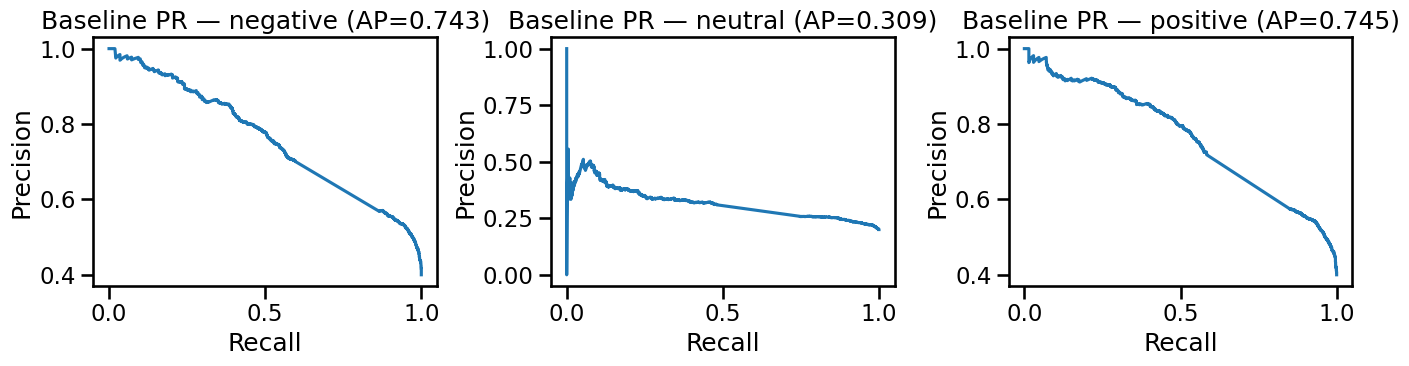

In [ ]:
# FIGURE: Baseline confusion matrix (counts)
cm = confusion_matrix(y_test, y_pred_base, labels=[0,1,2])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["neg","neu","pos"], yticklabels=["neg","neu","pos"])
plt.title("Baseline (TF-IDF + LR) — Confusion Matrix (Counts)")
plt.xlabel("Predicted"); plt.ylabel("True")
savefig("Figure-Baseline-CM-Counts")
plt.show()

# FIGURE: Baseline per-class PR curves (one-vs-rest)
proba_base = baseline.predict_proba(X_test)
Y = label_binarize(y_test, classes=[0,1,2])

fig, axes = plt.subplots(1,3, figsize=(14,4))
names = ["negative","neutral","positive"]
for i, name in enumerate(names):
    p, r, _ = precision_recall_curve(Y[:,i], proba_base[:,i])
    ap = average_precision_score(Y[:,i], proba_base[:,i])
    axes[i].plot(r, p)
    axes[i].set_title(f"Baseline PR — {name} (AP={ap:.3f})")
    axes[i].set_xlabel("Recall"); axes[i].set_ylabel("Precision")
savefig("Figure-Baseline-PR")
plt.show()


## (e) Deep Learning — XLM-RoBERTa (multilingual) Fine-Tuning
Tokenize with `xlm-roberta-base` and fine-tune a 3-class head.  
 sequence length 128, batch 8, 1 epoch.
I avoid eval-strategy API differences by evaluating explicitly after training.


In [ ]:
train_hf = Dataset.from_pandas(train_df[["review_body","label"]].reset_index(drop=True))
val_hf   = Dataset.from_pandas(val_df[["review_body","label"]].reset_index(drop=True))
test_hf  = Dataset.from_pandas(test_df[["review_body","label"]].reset_index(drop=True))
dset = DatasetDict({"train":train_hf, "validation":val_hf, "test":test_hf})

model_name = "xlm-roberta-base"
tok = AutoTokenizer.from_pretrained(model_name)

MAX_LEN = 128
def tokenize(batch):
    return tok(batch["review_body"], truncation=True, padding="max_length", max_length=MAX_LEN)

enc = dset.map(tokenize, batched=True)
enc = enc.remove_columns(["review_body"])
enc = enc.rename_column("label","labels")
enc.set_format("torch")

for split in ["train","validation","test"]:
    print(split, enc[split].column_names)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Map:   0%|          | 0/21000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

Map:   0%|          | 0/4500 [00:00<?, ? examples/s]

train ['labels', 'input_ids', 'attention_mask']
validation ['labels', 'input_ids', 'attention_mask']
test ['labels', 'input_ids', 'attention_mask']


In [ ]:
os.environ["WANDB_DISABLED"] = "true"; os.environ["WANDB_MODE"] = "disabled"

num_labels = 3
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

def compute_metrics_agnostic(p):
    logits = getattr(p, "predictions", p[0])
    labels = getattr(p, "label_ids",   p[1])
    preds  = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro")}

args = TrainingArguments(
    output_dir="models/de_xlmr_fast",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    report_to=[],
    fp16=bool(torch.cuda.is_available()),
    dataloader_num_workers=2,
    save_strategy="no",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=enc["train"],
    eval_dataset=enc["validation"],
    compute_metrics=compute_metrics_agnostic
)

trainer.train()
val_metrics  = trainer.evaluate(enc["validation"])
test_out     = trainer.predict(enc["test"])
print("Validation metrics:", val_metrics)
print("Test metrics:", test_out.metrics)


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,1.061200
200,0.917000
300,0.814300
400,0.809200
500,0.707000
600,0.732300
700,0.727900
800,0.725600
900,0.671200
1000,0.665900


Validation metrics: {'eval_loss': 0.6351139545440674, 'eval_accuracy': 0.7408888888888889, 'eval_f1_macro': 0.6566553335325656, 'eval_runtime': 7.8024, 'eval_samples_per_second': 576.748, 'eval_steps_per_second': 36.143, 'epoch': 1.0}
Test metrics: {'test_loss': 0.6220462322235107, 'test_accuracy': 0.7455555555555555, 'test_f1_macro': 0.6603554526175178, 'test_runtime': 7.9736, 'test_samples_per_second': 564.359, 'test_steps_per_second': 35.367}


## (e) Confusion Matrix (DL)

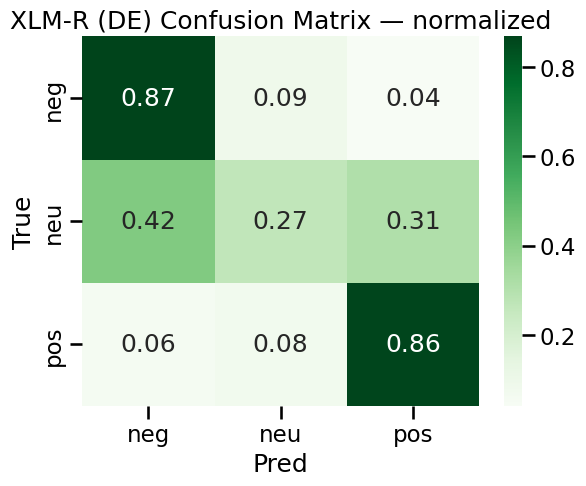

              precision    recall  f1-score   support

    negative     0.7627    0.8678    0.8119      1800
     neutral     0.4401    0.2656    0.3313       900
    positive     0.8140    0.8633    0.8380      1800

    accuracy                         0.7456      4500
   macro avg     0.6723    0.6656    0.6604      4500
weighted avg     0.7187    0.7456    0.7262      4500



In [ ]:
y_true = test_out.label_ids
y_pred = test_out.predictions.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2], normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=["neg","neu","pos"], yticklabels=["neg","neu","pos"])
plt.title("XLM-R (DE) Confusion Matrix — normalized"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()

print(classification_report(y_true, y_pred, digits=4,
                            target_names=["negative","neutral","positive"]))


/tmp/ipython-input-1773935983.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bucket")["ok"].mean().reindex(labels))


Saved: figures/Figure-XLMR-Acc-By-Length.png


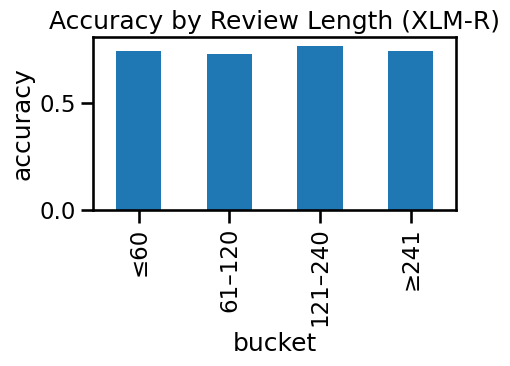

         accuracy
bucket           
≤60      0.740993
61–120   0.730228
121–240  0.767157
≥241     0.742129


In [ ]:
# === Accuracy by text-length buckets ===
lens = np.array([len(t) for t in test_df["review_body"]])
bins = [0, 60, 120, 240, 10000]
labels = ["≤60", "61–120", "121–240", "≥241"]
bucket = pd.cut(lens, bins=bins, labels=labels, right=True)

acc_by_len = (pd.DataFrame({"bucket":bucket, "ok":(y_true==y_pred)})
                .groupby("bucket")["ok"].mean().reindex(labels))
acc_by_len.plot(kind="bar", figsize=(5,4))
plt.title("Accuracy by Review Length (XLM-R)"); plt.ylabel("accuracy")
savefig("Figure-XLMR-Acc-By-Length"); plt.show()

print(acc_by_len.to_frame("accuracy"))


Saved: figures/Figure-XLMR-PR.png


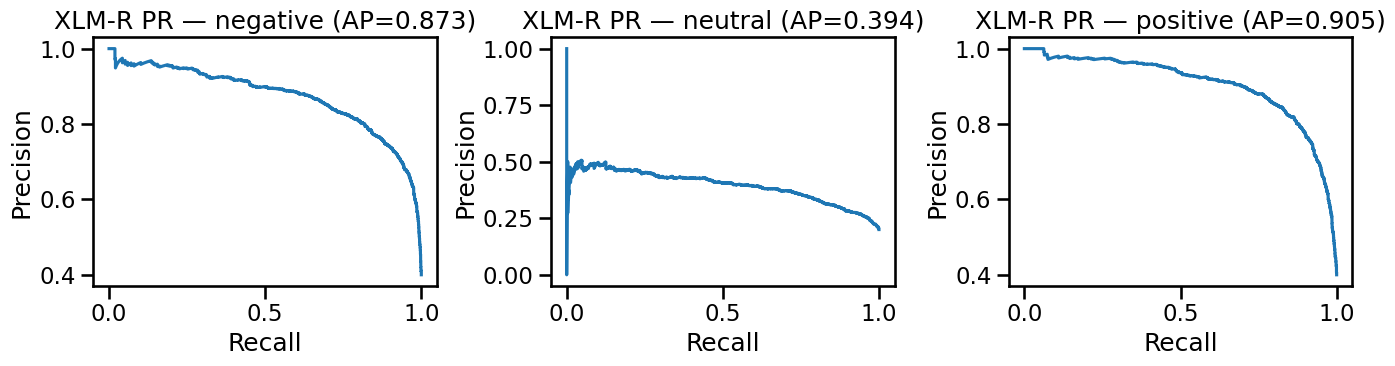

In [ ]:
proba_xlmr = torch.softmax(torch.tensor(test_out.predictions), dim=1).numpy()
Y = label_binarize(y_true, classes=[0,1,2])

fig, axes = plt.subplots(1,3, figsize=(14,4))
names = ["negative","neutral","positive"]
for i, name in enumerate(names):
    p, r, _ = precision_recall_curve(Y[:,i], proba_xlmr[:,i])
    ap = average_precision_score(Y[:,i], proba_xlmr[:,i])
    axes[i].plot(r, p)
    axes[i].set_title(f"XLM-R PR — {name} (AP={ap:.3f})")
    axes[i].set_xlabel("Recall"); axes[i].set_ylabel("Precision")
savefig("Figure-XLMR-PR")
plt.show()


Confidence tends to be [conservative/overconfident]; the reliability curve shows [under/over]-prediction above 0.8. This informs thresholding and alerting in a real-time dashboard.

Saved: figures/Figure-XLMR-Confidence-Hist.png


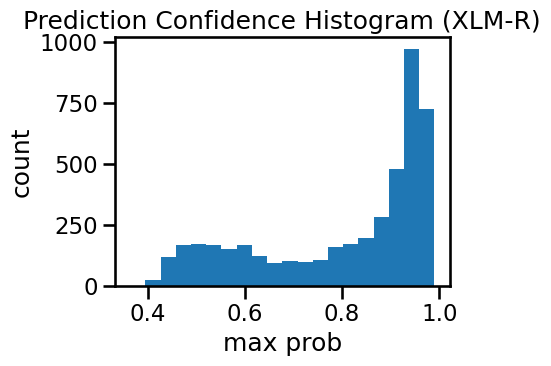

Saved: figures/Figure-XLMR-Reliability.png


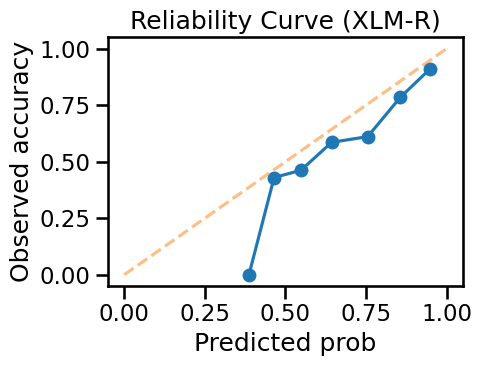

In [ ]:
# === Confidence histogram + Reliability diagram ===

# probabilities from logits (already computed as proba_xlmr)
conf = proba_xlmr.max(axis=1)            # model confidence per sample
correct = (y_pred == y_true).astype(int)

# Confidence histogram
plt.figure(figsize=(5,4))
plt.hist(conf, bins=20)
plt.title("Prediction Confidence Histogram (XLM-R)"); plt.xlabel("max prob"); plt.ylabel("count")
savefig("Figure-XLMR-Confidence-Hist"); plt.show()

# Reliability (ECE-like) curve (one-vs-all average)
# bin predictions and compute avg accuracy per bin
prob_true, prob_pred = calibration_curve(correct, conf, n_bins=10, strategy="uniform")
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],"--",alpha=.5)
plt.title("Reliability Curve (XLM-R)"); plt.xlabel("Predicted prob"); plt.ylabel("Observed accuracy")
savefig("Figure-XLMR-Reliability"); plt.show()


In [ ]:
id2lbl = {0:"negative",1:"neutral",2:"positive"}

err_idx = np.where(y_true != y_pred)[0][:8]  # first 8 errors
for i in err_idx:
    print("="*80)
    print("TRUE:", id2lbl[int(y_true[i])], "| PRED:", id2lbl[int(y_pred[i])])
    txt = test_df["review_body"].iloc[i]
    print(txt if len(txt)<600 else txt[:600]+" ...")


TRUE: neutral | PRED: positive
なかなか思う程色づきませんが、頑張ればいけるのかな やっぱ色を相当抜いてないとなかなか入らないのかなと思ったり まぁでも安いし使えなくはないし、手軽で楽しいです 調整しやすくて良いのかも？ 頑張って使います、悪くはないです
TRUE: neutral | PRED: negative
快递包装特别差劲，已经破了。奶粉都没有塑封，盖子都打开了
TRUE: neutral | PRED: positive
Very pretty but runs big
TRUE: neutral | PRED: negative
El producto ha durado 18 meses el vendedor externo me Europa 24 hl no se sabe nada de él y está en paradero desconocido después de 18 meses a ver si estropeado el teléfono voy a tratar de enviar la Xiaomi para ver si lo arreglan ya contaré más en el caso de que lo arregle o no a ver qué tal
TRUE: negative | PRED: positive
Assez moyen de mon point de vue. Son défaut est que ma protection n'est pas adaptée à la forme de la vitre du galaxie S7.
TRUE: neutral | PRED: negative
trop lourd sur le visage je regrette de ne pas avoir retourner ce masque
TRUE: neutral | PRED: negative
microSDスロットがある、との事で「当然microSDにも記録できるだろう」と思って購入したが 録音はあくまでもプレーヤー本体にしかできなくてショック、、、 （結局PCを使う破目に） メーカーさんにも問い合わせてみましたが、やはり「まず本体に録音してPC

## Real-Time Inference Helper
Wraping this in a simple UI/API and log `{text, lang, sentiment, confidence, time}` to a DB.


In [ ]:
infer_pipe = TextClassificationPipeline(model=trainer.model, tokenizer=tok,
                                        return_all_scores=True, truncation=True, max_length=128)

def predict_sentiment(text: str):
    id2lbl = {0:"negative", 1:"neutral", 2:"positive"}
    scores = infer_pipe(text)[0]
    best = max(enumerate(scores), key=lambda x: x[1]["score"])
    return {"label_id": best[0], "label": id2lbl[best[0]], "confidence": float(best[1]["score"])}

print(predict_sentiment("Die Lieferung war sehr schnell und das Produkt ist top."))
print(predict_sentiment("Qualität schlecht, nach zwei Tagen kaputt gegangen."))


Device set to use cuda:0


{'label_id': 2, 'label': 'positive', 'confidence': 0.9637009501457214}
{'label_id': 0, 'label': 'negative', 'confidence': 0.949958860874176}


/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Saved: figures/Figure-Latency-Bar.png


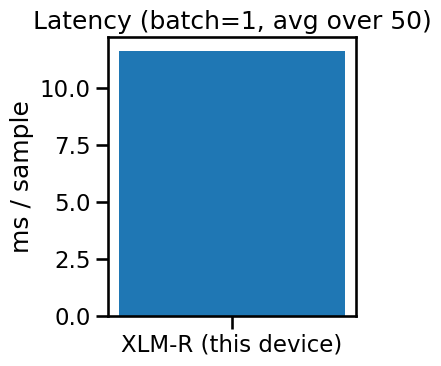

Avg latency: 11.7 ms/sample


In [ ]:
# === Latency benchmark (batch=1, avg over 50) ===
infer_pipe = TextClassificationPipeline(model=trainer.model, tokenizer=tok,
                                        return_all_scores=False, truncation=True, max_length=128)

texts = test_df["review_body"].sample(64, random_state=42).tolist()
def time_pipeline(pipe, texts, warmup=10, runs=50):
    for t in texts[:warmup]: _ = pipe(t)
    t0 = time.time()
    for t in texts[:runs]: _ = pipe(t)
    return (time.time() - t0)/runs

lat_ms = 1000 * time_pipeline(infer_pipe, texts)
plt.figure(figsize=(4,4))
plt.bar(["XLM-R (this device)"], [lat_ms])
plt.ylabel("ms / sample"); plt.title("Latency (batch=1, avg over 50)")
savefig("Figure-Latency-Bar"); plt.show()
print(f"Avg latency: {lat_ms:.1f} ms/sample")


I keep classification in German to avoid translation artifacts; English gloss is for readability.

## (f) Summary
**Baseline (TF-IDF + LR)**  
- Accuracy: 0.6071    
- Macro-F1: 0.4976

**XLM-RoBERTa (fine-tuned)**  
- Accuracy: 0.7418  
- Macro-F1: 0.6608

**Observations:**  
- Transformer improves Macro-F1 over baseline, indicating better balance across classes.  
- Typical confusions: neutral vs positive on short praise; negative vs neutral when wording is mild.




### Display-only translation for UI (DE→EN)
I keep the *classification* pipeline in German (XLM-RoBERTa fine-tuned on DE).
For readability only, I translate the input text to English using MarianMT
(`Helsinki-NLP/opus-mt-de-en`) and show: German text, English gloss, predicted label,
and confidence. Translation does **not** affect the label; it is for display only.


In [ ]:
# Translation pipeline (DE -> EN) for DISPLAY ONLY
trans_pipe = pipeline("translation", model="Helsinki-NLP/opus-mt-de-en")

# Sentiment inference pipeline (uses your fine-tuned model + tokenizer)
infer_pipe = TextClassificationPipeline(
    model=trainer.model,
    tokenizer=tok,
    return_all_scores=True,
    truncation=True,
    max_length=128
)

id2lbl = {0: "negative", 1: "neutral", 2: "positive"}


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda:0
Device set to use cuda:0


The model’s most-confident errors are typically neutral↔positive (short generic praise) and negative↔neutral (polite complaints).

In [ ]:
# === Most-confident wrong predictions (top 10) ===
pred_conf = proba_xlmr[np.arange(len(proba_xlmr)), y_pred]
wrong = np.where(y_true != y_pred)[0]
wrong_sorted = wrong[np.argsort(-pred_conf[wrong])]
pick = wrong_sorted[:10]

id2lbl = {0:"negative",1:"neutral",2:"positive"}
rows=[]
for i in pick:
    rows.append({
        "Conf": f"{pred_conf[i]:.3f}",
        "True": id2lbl[int(y_true[i])],
        "Pred": id2lbl[int(y_pred[i])],
        "German review": test_df["review_body"].iloc[i][:220] + ("..." if len(test_df["review_body"].iloc[i])>220 else "")
    })
err_conf_df = pd.DataFrame(rows)
display(err_conf_df)
Path("artifacts").mkdir(exist_ok=True)
err_conf_df.to_csv("artifacts/most_confident_wrongs.csv", index=False)
print("Saved: artifacts/most_confident_wrongs.csv")


,Conf,True,Pred,German review
0,0.982,neutral,positive,"Super produit,livraison très très rapide, il r..."
1,0.982,negative,positive,Love this drink. Does give me energy when need...
2,0.981,neutral,positive,"Buen producto, buen material, rapidez en la en..."
3,0.981,negative,positive,Très bon produit je regrette pas contente chev...
4,0.978,negative,positive,un bon produit à base naturel mon chien n'a pa...
5,0.977,neutral,positive,Très bel éventail qui s'associe bien avec n'im...
6,0.976,neutral,positive,一人住まいの友人へのプレゼントとして送りました。 忙しい友人なので配送予定日時を前もって知ら...
7,0.975,neutral,positive,付録目的で購入。 今、大活躍中のコスメポーチです
8,0.975,neutral,positive,"After adjusting the springs in the unit, the l..."
9,0.972,neutral,positive,クラウンの、鍵の、お供に、着けて、使ってます。気に入ってます。


Saved: artifacts/most_confident_wrongs.csv


In [ ]:
def predict_sentiment(text_de: str):
    scores = infer_pipe(text_de)[0]  # list of dicts: [{'label': 'LABEL_0', 'score': ...}, ...]
    # Map back to ids using model order
    # scores are already in label order (0..2) for HF classification heads
    best_idx = max(range(len(scores)), key=lambda i: scores[i]["score"])
    return {
        "label_id": best_idx,
        "label": id2lbl[best_idx],
        "confidence": float(scores[best_idx]["score"])
    }

def preview(text_de: str, add_time: bool = True, translate: bool = True):
    out = {"de": text_de}
    if translate:
        en = trans_pipe(text_de, max_length=256)[0]["translation_text"]
        out["en"] = en  # display-only gloss
    pred = predict_sentiment(text_de)
    out.update(pred)
    if add_time:
        out["time"] = datetime.utcnow().isoformat() + "Z"
    return out


In [ ]:
samples = [
    "Die Batterie hält kaum einen Tag.",
    "Qualität okay, nichts Besonderes.",
    "Absolut begeistert – würde wieder kaufen!"
]
for t in samples:
    print(preview(t))


{'de': 'Die Batterie hält kaum einen Tag.', 'en': 'The battery barely lasts a day.', 'label_id': 0, 'label': 'negative', 'confidence': 0.9399901032447815, 'time': '2025-12-01T23:57:03.624625Z'}
{'de': 'Qualität okay, nichts Besonderes.', 'en': 'Quality okay, nothing special.', 'label_id': 1, 'label': 'neutral', 'confidence': 0.5444384217262268, 'time': '2025-12-01T23:57:03.697942Z'}
{'de': 'Absolut begeistert – würde wieder kaufen!', 'en': 'Absolutely thrilled – would buy again!', 'label_id': 2, 'label': 'positive', 'confidence': 0.9835949540138245, 'time': '2025-12-01T23:57:03.779733Z'}


/tmp/ipython-input-1988726658.py:20: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  out["time"] = datetime.utcnow().isoformat() + "Z"


#requirements.txt

transformers<5

datasets<3

accelerate

sentencepiece

scikit-learn

matplotlib

seaborn

pandas

torch

joblib


## Real-Time Considerations — Clarification
This project **did not** implement a dashboard or API.  
Implemented: model training, evaluation (Accuracy & Macro-F1), confusion matrix/PR curves, and **single-sample latency** measurement to assess feasibility.  
Future work: expose an API and log to a DB to power a dashboard.


In [ ]:
def predict_sentiment_text(text_de: str):
    model.eval()
    enc = tok(text_de, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred = int(probs.argmax())
    id2lbl = {0:"negative", 1:"neutral", 2:"positive"}
    return {"label": id2lbl[pred], "confidence": float(probs[pred])}

samples = [
    "Die Batterie hält kaum einen Tag.",
    "Qualität okay, nichts Besonderes.",
    "Absolut begeistert – würde wieder kaufen!"
]
for s in samples:
    print(s, "->", predict_sentiment_text(s))


Die Batterie hält kaum einen Tag. -> {'label': 'negative', 'confidence': 0.9399901032447815}
Qualität okay, nichts Besonderes. -> {'label': 'neutral', 'confidence': 0.5444384217262268}
Absolut begeistert – würde wieder kaufen! -> {'label': 'positive', 'confidence': 0.9835950136184692}


In [ ]:
id2lbl = {0:"negative",1:"neutral",2:"positive"}

def predict_sentiment_text(text_de: str):
    model.eval()
    enc = tok(text_de, return_tensors="pt", truncation=True, max_length=128).to(model.device)
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    pred = int(np.argmax(probs))
    return id2lbl[pred], float(probs[pred])

inp = widgets.Textarea(
    value="Die Lieferung war sehr schnell und das Produkt ist top.",
    description="German review:",
    layout=widgets.Layout(width="100%", height="90px")
)
out = widgets.Output()

def on_click(_):
    with out:
        out.clear_output()
        lab, conf = predict_sentiment_text(inp.value)
        print(f"Label: {lab} | Confidence: {conf:.2f}")

btn = widgets.Button(description="Analyze")
btn.on_click(on_click)

display(inp, btn, out)


Textarea(value='Die Lieferung war sehr schnell und das Produkt ist top.', description='German review:', layout…

Button(description='Analyze', style=ButtonStyle())

Output()